In [1]:

import kagglehub

path = kagglehub.dataset_download("andrewmvd/road-sign-detection")

print("Path to dataset files:", path)

100%|██████████| 218M/218M [00:01<00:00, 134MB/s]  

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/andrewmvd/road-sign-detection/versions/1


In [2]:
!ls $path

annotations  images


In [3]:
import os
os.environ["HF_TOKEN"] = "***************your_huggingface_token***************"
import io
import shutil
import requests
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from PIL import Image
from tqdm import tqdm
 
!pip install lxml
from lxml import etree

!pip install ultralytics
from ultralytics import YOLO

!pip install transformers pillow torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch

from PIL import Image, ImageDraw, ImageFont

!pip install pyttsx3
import pyttsx3
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Looking in indexes: https://download.pytorch.org/whl/cu121


In [4]:
import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nazwa karty: {torch.cuda.get_device_name(0)}")

CUDA: True
Nazwa karty: Tesla T4


In [5]:
epochs = 20
class_dict = {"stop": 0, "speedlimit": 1, "crosswalk": 2, "trafficlight": 3}

In [6]:
def split_train_test(path: str, train_size: float = 0.8, val_size: float = 0.1, seed: int = None):
    if seed is not None:
        np.random.seed(seed)

    annots = np.array(os.listdir(os.path.join(path, "annotations")))
    imgs = np.array(os.listdir(os.path.join(path, "images")))

    annots.sort()
    imgs.sort()

    train_len = int(len(annots) * train_size)
    val_len = int(len(annots) * val_size)
    test_len = len(annots) - train_len - val_len

    indices = np.arange(len(annots), dtype=int)
    np.random.shuffle(indices)

    train_idx = indices[:train_len]
    val_idx = indices[:train_len + val_len]
    test_idx = indices[train_len+val_len:]

    train_annots = annots[train_idx]
    train_imgs = imgs[train_idx]

    val_annots = annots[val_idx]
    val_imgs = imgs[val_idx]

    test_annots = annots[test_idx]
    test_imgs = imgs[test_idx]

    return (train_annots, train_imgs), (val_annots, val_imgs), (test_annots, test_imgs)

In [7]:
train, val, test = split_train_test(path, 0.8, 0.1, seed=42)

In [8]:
def extract_data(xml_file: str):
    tree = etree.parse(xml_file)
    root = tree.getroot()

    img_path = root.find("filename").text

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    boxes = []
    labels = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        bndbox = obj.find("bndbox")

        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)

        labels.append(class_name)
        boxes.append([xmin, ymin, xmax, ymax])

    return img_path, width, height, boxes, labels

In [9]:

def rcnn_to_yolo(img_w, img_h, xmin, ymin, xmax, ymax):
    x_abs = (xmin + xmax) / 2
    y_abs = (ymin + ymax) / 2
    w_abs = xmax - xmin
    h_abs = ymax - ymin

    xc = x_abs / img_w
    yc = y_abs / img_h
    w = w_abs / img_w
    h = h_abs / img_h

    return xc, yc, w, h

In [10]:
def create_yolo_files(data: tuple, folder: str):
  os.makedirs(f"{folder}/labels", exist_ok=True)
  os.makedirs(f"{folder}/images", exist_ok=True)

  for (annots, imgs) in data:
    for i in tqdm(range(len(annots))):
      img_path, width, height, boxes, labels = extract_data(os.path.join(path, "annotations", annots[i]))

      result = []
      for j in range(len(boxes)):
         xmin, ymin, xmax, ymax = boxes[j]
         class_id = class_dict[labels[j]]

         box = rcnn_to_yolo(width, height, xmin, ymin, xmax, ymax)
         result.append(f"{class_id} {' '.join(str(x) for x in box)}")

      with open(f"{folder}/labels/{i}.txt", "w") as f:
         content = "\n".join(result)
         f.write(content)

      shutil.copy(os.path.join(path, "images", img_path), f"{folder}/images/{i}.jpg")

In [11]:
create_yolo_files([val], "data/val")
create_yolo_files([train], "data/train")
create_yolo_files([test], "data/test")

100%|██████████| 89/89 [00:00<00:00, 1766.59it/s]


In [12]:
def create_yaml(root: str, train: str, valid: str, classes: list):
  """ Create dataset.yaml """
  nc = len(classes)
  content = f"""
path: {root}
train: {train}
val: {valid}

nc: {nc}
names: {classes}
  """
  with open("dataset.yaml", "w") as f:
      f.write(content)
  print("Created dataset.yaml!")

In [13]:
create_yaml("data", "train", "val", list(class_dict.keys()))

Created dataset.yaml!


In [14]:
!cat dataset.yaml


path: data
train: train
val: val

nc: 4
names: ['stop', 'speedlimit', 'crosswalk', 'trafficlight']
  

In [15]:
model = YOLO("yolo26s.pt")

In [ ]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
model_ocr = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed').to(device)

model.train(data="dataset.yaml", batch=64, epochs=epochs, imgsz=640, device='gpu',workers=0,)

In [18]:
best_model = YOLO("runs/detect/train/weights/best.pt")

In [ ]:
test_imgs = glob("data/test/images/*.jpg")

results = best_model.predict(test_imgs[:5], imgsz=320)

fig, axes = plt.subplots(1, len(results), figsize=(15, 5))

for ax, result in zip(axes, results):
    img = result.plot()  
    ax.imshow(img[:, :, ::-1]) 
    ax.axis("off")

plt.suptitle("Model's prediction")
plt.tight_layout()
plt.show()


0: 320x256 2 stops, 2 trafficlights, 13.0ms
1: 320x256 2 speedlimits, 13.0ms
2: 320x256 2 crosswalks, 13.0ms
3: 320x256 1 speedlimit, 13.0ms
4: 320x256 1 speedlimit, 13.0ms
Speed: 0.4ms preprocess, 13.0ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 256)


<Figure size 1500x500 with 5 Axes>

In [ ]:
def predict_and_show(img_path, yolo_model):
    results = yolo_model.predict(img_path, conf=0.5)
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            class_id = int(box.cls)
            label = yolo_model.names[class_id]

            if label == 'speedlimit':
                crop = img.crop((max(0, x1-5), max(0, y1-5), x2+5, y2+5))
                
                pixel_values = processor(images=crop, return_tensors="pt").pixel_values.to(device)
                generated_ids = model_ocr.generate(pixel_values)
                text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
                
                clean_text = ''.join(filter(str.isdigit, text))
                display_label = f"Limit: {clean_text}" if clean_text else "Sign"
            else:
                display_label = label

            draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
            draw.text((x1, y1 - 10), display_label, fill="red")
    
    return img


image 1/1 /Users/sebastianstarzec/Documents/Magisterka/Semestr 4/projektNlp/data/test/images/80.jpg: 320x256 1 speedlimit, 21.8ms
Speed: 0.5ms preprocess, 21.8ms inference, 0.1ms postprocess per image at shape (1, 3, 320, 256)


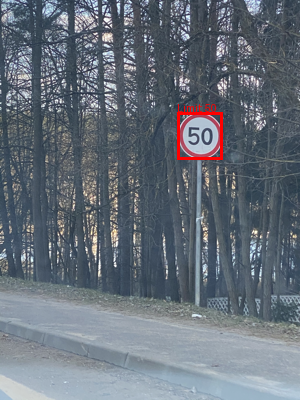

In [ ]:
model_path = "runs/detect/train3/weights/best.pt"
trained_model = YOLO(model_path)

test_img = "data/test/images/1.jpg" 

result_img = predict_and_show(test_img, trained_model)

display(result_img)